In [1]:
# Do NOT upgrade torch/numpy here: Colab ships matching versions, and upgrading only some of them
# causes "Could not import module 'pipeline'". After this cell finishes, if Colab asks, restart the session.
!pip install -q -U transformers huggingface_hub scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.4 MB/s eta 0:00:00


## 1. Load detectors

In [2]:
import os, re, io, requests
import numpy as np
import torch
from io import BytesIO
from PIL import Image, ImageOps
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print("Device:", "GPU" if device == 0 else "CPU")

# Detectors to try. Any that no longer exist or fail to load are skipped automatically.
CANDIDATES = [
    "Organika/sdxl-detector",
    "umm-maybe/AI-image-detector",
    "Ateeqq/ai-vs-human-image-detector",
    "dima806/ai_vs_real_image_detection",
    "haywoodsloan/ai-image-detector-deploy",
]
EXTRA = []   # add more model ids here (see the optional discovery cell below)

# If a model uses generic labels like LABEL_0 / LABEL_1, tell the notebook what they mean.
# Check the model card, then e.g.:
# LABEL_OVERRIDE = {"some/model": {"LABEL_0": "real", "LABEL_1": "ai"}}
LABEL_OVERRIDE = {}

detectors = {}
for name in CANDIDATES + EXTRA:
    try:
        detectors[name] = pipeline("image-classification", model=name, device=device)
        print("OK     ", name, "| labels:", list(detectors[name].model.config.id2label.values()))
    except Exception as e:
        print("SKIPPED", name, "->", str(e)[:100])

print(f"\n{len(detectors)} detector(s) loaded")

Device: CPU


config.json:   0%|          | 0.00/1.13k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  347MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  781MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

OK      haywoodsloan/ai-image-detector-deploy | labels: ['artificial', 'real']

5 detector(s) loaded


### Optional: discover more detectors from the Hub

In [3]:
from huggingface_hub import HfApi
api = HfApi()
queries = ["ai generated image detector", "ai vs real image", "ai image detector",
           "synthetic image detection", "flux detector", "midjourney detector"]
found = {}
for q in queries:
    try:
        for m in api.list_models(search=q, pipeline_tag="image-classification",
                                 sort="downloads", limit=20):
            found[m.id] = m
    except Exception as e:
        print("Search failed:", q, "->", e)

rows = sorted(((m.id, getattr(m, "downloads", 0) or 0, getattr(m, "likes", 0) or 0)
               for m in found.values()), key=lambda r: r[1], reverse=True)
for i, (mid, dl, lk) in enumerate(rows):
    print(f"{i:<3} {mid:<55} downloads={dl:<9} likes={lk}")
print("\nCopy promising ids into EXTRA above, then re-run the loading cell.")
print("Check each model card: face-only deepfake detectors will not work on general images.")

0   umm-maybe/AI-image-detector                             downloads=94214     likes=100
1   dima806/ai_vs_real_image_detection                      downloads=28419     likes=21
2   Ateeqq/ai-vs-human-image-detector                       downloads=14492     likes=67
3   haywoodsloan/ai-image-detector-deploy                   downloads=7033      likes=26
4   haywoodsloan/ai-image-detector-dev-deploy               downloads=2908      likes=10
5   Smogy/SMOGY-Ai-images-detector                          downloads=2578      likes=3
6   NYUAD-ComNets/NYUAD_AI-generated_images_detector        downloads=1310      likes=11
7   onnx-community/SMOGY-Ai-images-detector-ONNX            downloads=319       likes=2
8   Bombek1/ai-image-detector-siglip-dinov2                 downloads=279       likes=9
9   mmanikanta/VIT_AI_image_detector                        downloads=214       likes=0
10  Hemgg/AI-vs-Real-Image-Detection                        downloads=200       likes=0
11  mmanikanta/SWIN-AI-Im

## 2. Helper functions

In [4]:
AI_TOKENS   = {"ai", "artificial", "fake", "generated", "synthetic", "deepfake", "gan", "diffusion",
               "sd", "sdxl", "midjourney", "dalle", "flux", "aigc", "generative", "machine"}
REAL_TOKENS = {"real", "human", "hum", "authentic", "natural", "genuine", "photo", "camera",
               "nature", "original"}
NEG_TOKENS  = {"not", "non", "no", "isnt"}

def classify_label(label):
    """Return 'ai', 'real' or None (unknown) for a class label. Whole-word matching only."""
    toks = re.findall(r"[a-z0-9]+", label.lower())
    neg = any(t in NEG_TOKENS for t in toks)
    has_ai = any(t in AI_TOKENS for t in toks)
    has_real = any(t in REAL_TOKENS for t in toks)
    if has_ai == has_real:          # neither, or ambiguous
        return None
    if has_ai:
        return "real" if neg else "ai"
    return "ai" if neg else "real"

def p_ai_from(result, model_name=None):
    """Convert a pipeline result (list of {label, score}) into P(AI-generated)."""
    ov = LABEL_OVERRIDE.get(model_name, {})
    p_ai = p_real = 0.0
    seen_ai = seen_real = False
    for r in result:
        kind = ov.get(r["label"]) or classify_label(r["label"])
        if kind == "ai":
            p_ai += r["score"]; seen_ai = True
        elif kind == "real":
            p_real += r["score"]; seen_real = True
    if seen_real:
        return 1.0 - p_real          # everything that is not 'real' counts as AI
    if seen_ai:
        return p_ai
    return None                      # labels not understood -> use LABEL_OVERRIDE

def make_crops(im, crop=224, n=3):
    """Native-resolution crops on an n x n grid (keeps fine generator artifacts)."""
    w, h = im.size
    if min(w, h) < crop:
        return []
    xs = np.linspace(0, w - crop, n).astype(int)
    ys = np.linspace(0, h - crop, n).astype(int)
    return [im.crop((int(x), int(y), int(x) + crop, int(y) + crop)) for y in ys for x in xs]

def score_image(im, mode="max"):
    """mode: 'full' (whole image), 'crops' (mean over crops) or 'max' of the two."""
    crops = make_crops(im)
    out = {}
    for name, det in detectors.items():
        try:
            full = p_ai_from(det(im, top_k=None), name)
            cp = []
            if crops:
                cp = [p_ai_from(o, name) for o in det(crops, top_k=None, batch_size=8)]
                cp = [p for p in cp if p is not None]
            crop_mean = float(np.mean(cp)) if cp else None
            cand = {"full": [full], "crops": [crop_mean], "max": [full, crop_mean]}[mode]
            cand = [c for c in cand if c is not None]
            out[name] = {"full": full, "crops": crop_mean, "score": max(cand) if cand else None}
        except Exception as e:
            out[name] = {"full": None, "crops": None, "score": None, "error": str(e)[:80]}
    return out

# Strong = tools that explicitly mark their output as AI. Provenance = signed content credentials
# (present on AI images, but real cameras can carry them too, so verify before concluding).
STRONG_MARKERS = ["trainedalgorithmicmedia", "compositewithtrainedalgorithmicmedia",
                  "stable diffusion", "midjourney", "dall-e", "dalle", "firefly", "comfyui",
                  "automatic1111", "sdxl", "synthid"]
PROVENANCE_MARKERS = ["c2pa", "jumbf", "contentcredentials"]

def check_metadata(raw_img, data):
    blob = (str(raw_img.info) + str(dict(raw_img.getexif()))).lower()
    low = data.lower()
    strong = [k for k in STRONG_MARKERS if k in blob or k.encode() in low]
    prov = [k for k in PROVENANCE_MARKERS if k in blob or k.encode() in low]
    return {"strong": strong, "provenance": prov}

def verdict(scores, meta, threshold=0.5, high=0.85):
    vals = {n: s["score"] for n, s in scores.items() if s["score"] is not None}
    mx = max(vals.values()) if vals else None
    mean = float(np.mean(list(vals.values()))) if vals else None
    reasons = []
    if meta["strong"]:
        return "AI-GENERATED (file metadata names an AI tool)", [f"metadata markers: {meta['strong']}"]
    if mx is not None and mx >= high:
        best = max(vals, key=vals.get)
        return "LIKELY AI-GENERATED", [f"{best} is highly confident ({mx:.0%})"]
    if mean is not None and mean >= threshold:
        return "LIKELY AI-GENERATED", [f"ensemble mean {mean:.0%} >= threshold {threshold:.0%}"]
    if meta["provenance"]:
        reasons.append(f"content-credential markers present: {meta['provenance']} (verify them)")
    reasons.append("no detector flagged it, but detectors cannot recognise generators they were "
                   "not trained on, so this does NOT prove the image is real")
    return "INCONCLUSIVE (no AI evidence found)", reasons

fmt = lambda x: "n/a" if x is None else f"{x:.1%}"
print("Helpers ready")

Helpers ready


## 3. Load your image

Type 'u' to upload or 'l' for an image link: u


Saving Gemini_Generated_Image_cgixn6cgixn6cgix.png to Gemini_Generated_Image_cgixn6cgixn6cgix (1).png
Format: PNG | Size: (1408, 768) | File size: 2275 KB
Weak hint: both sides are multiples of 64, which is typical of generator output (not proof).


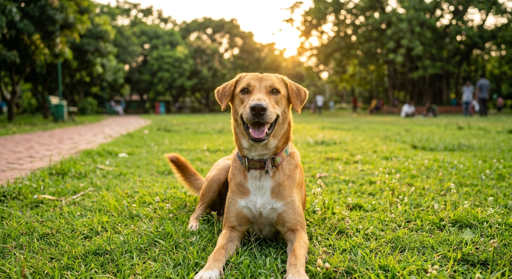

In [15]:
from google.colab import files

choice = input("Type 'u' to upload or 'l' for an image link: ").strip().lower()
if choice == "l":
    url = input("Image URL: ").strip()
    data = requests.get(url, timeout=20, headers={"User-Agent": "Mozilla/5.0"}).content
else:
    up = files.upload()
    data = open(list(up.keys())[0], "rb").read()

raw = Image.open(BytesIO(data))
img_full = ImageOps.exif_transpose(raw).convert("RGB")   # full resolution, never shrunk
print("Format:", raw.format, "| Size:", raw.size, "| File size:", f"{len(data)/1024:.0f} KB")

if min(raw.size) < 256:
    print("WARNING: very small image, detectors are unreliable below ~256 px.")
if raw.format == "JPEG" and not raw.getexif():
    print("NOTE: JPEG without camera EXIF. May be a re-saved/social-media copy; compression weakens detection.")
if raw.size[0] % 64 == 0 and raw.size[1] % 64 == 0 and max(raw.size) >= 512:
    print("Weak hint: both sides are multiples of 64, which is typical of generator output (not proof).")

preview = img_full.copy()
preview.thumbnail((512, 512))      # preview only; detection uses img_full
preview

## 4. Detect

In [16]:
SCORE_MODE = "max"     # "full" | "crops" | "max"  (max is more sensitive; confirm on real photos)
THRESHOLD  = 0.5
HIGH_CONF  = 0.85

meta = check_metadata(raw, data)
print("Metadata -> strong AI markers:", meta["strong"] or "none",
      "| provenance markers:", meta["provenance"] or "none")

scores = score_image(img_full, mode=SCORE_MODE)

print(f"\n{'model':<45} {'full image':>11} {'crops(mean)':>12} {'score':>8}")
for name, s in scores.items():
    note = "   <- labels not understood, set LABEL_OVERRIDE" if s["score"] is None and "error" not in s else ""
    note = note or (f"   <- error: {s['error']}" if "error" in s else "")
    print(f"{name:<45} {fmt(s['full']):>11} {fmt(s['crops']):>12} {fmt(s['score']):>8}{note}")

v, reasons = verdict(scores, meta, THRESHOLD, HIGH_CONF)
print("\nVERDICT:", v)
for r in reasons:
    print(" -", r)

if "clf" in globals():
    names = list(detectors)
    x = np.array([[scores[n]["score"] if scores[n]["score"] is not None else 0.5 for n in names]])
    print(f"Calibrated P(AI) from your own data: {clf.predict_proba(x)[0, 1]:.1%}")

Metadata -> strong AI markers: ['trainedalgorithmicmedia', 'synthid'] | provenance markers: ['c2pa', 'jumbf']

model                                          full image  crops(mean)    score
Organika/sdxl-detector                               0.0%         0.7%     0.7%
umm-maybe/AI-image-detector                         23.3%        22.6%    23.3%
Ateeqq/ai-vs-human-image-detector                    0.4%        12.6%    12.6%
dima806/ai_vs_real_image_detection                  83.1%        54.7%    83.1%
haywoodsloan/ai-image-detector-deploy               16.6%        66.3%    66.3%

VERDICT: AI-GENERATED (file metadata names an AI tool)
 - metadata markers: ['trainedalgorithmicmedia', 'synthid']


## 5. Optional: calibrate on your own images (most reliable fix)

Pretrained detectors disagree and each only knows certain generators. If you give the notebook some
labelled examples of **your** kind of images, it learns which detectors to trust.

1. In the Colab file panel create two folders: `real/` and `ai/`.
2. Put at least ~15 images in each (real = untouched photos; ai = images from the generators you care about).
3. Run the cell below.

In [9]:
'''from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def load_folder(folder):
    out = []
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            out.append(os.path.join(folder, f))
    return out

paths = [(p, 0) for p in load_folder("real")] + [(p, 1) for p in load_folder("ai")]
names = list(detectors)
X, y = [], []
for p, lab in paths:
    im = ImageOps.exif_transpose(Image.open(p)).convert("RGB")
    sc = score_image(im, mode=SCORE_MODE)
    X.append([sc[n]["score"] if sc[n]["score"] is not None else 0.5 for n in names])
    y.append(lab)
X, y = np.array(X), np.array(y)
print(f"{len(y)} images ({int((y==0).sum())} real, {int((y==1).sum())} AI)")

print("\nPer-detector accuracy at threshold 0.5:")
for i, n in enumerate(names):
    print(f"  {n:<45} {((X[:, i] >= 0.5) == y).mean():.0%}")

clf = LogisticRegression(class_weight="balanced", max_iter=1000).fit(X, y)
k = min(5, int(min((y == 0).sum(), (y == 1).sum())))
if k >= 2:
    print(f"\nCombined (calibrated) accuracy, {k}-fold cross-validated: "
          f"{cross_val_score(LogisticRegression(class_weight='balanced', max_iter=1000), X, y, cv=k).mean():.0%}")
print("Learned weights:", dict(zip(names, np.round(clf.coef_[0], 2))))
print("Re-run the Detect cell: it now also prints a calibrated probability.")'''

'from sklearn.linear_model import LogisticRegression\nfrom sklearn.model_selection import cross_val_score\n\ndef load_folder(folder):\n    out = []\n    for f in sorted(os.listdir(folder)):\n        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):\n            out.append(os.path.join(folder, f))\n    return out\n\npaths = [(p, 0) for p in load_folder("real")] + [(p, 1) for p in load_folder("ai")]\nnames = list(detectors)\nX, y = [], []\nfor p, lab in paths:\n    im = ImageOps.exif_transpose(Image.open(p)).convert("RGB")\n    sc = score_image(im, mode=SCORE_MODE)\n    X.append([sc[n]["score"] if sc[n]["score"] is not None else 0.5 for n in names])\n    y.append(lab)\nX, y = np.array(X), np.array(y)\nprint(f"{len(y)} images ({int((y==0).sum())} real, {int((y==1).sum())} AI)")\n\nprint("\nPer-detector accuracy at threshold 0.5:")\nfor i, n in enumerate(names):\n    print(f"  {n:<45} {((X[:, i] >= 0.5) == y).mean():.0%}")\n\nclf = LogisticRegression(class_weight="balanced", max_i